# 结肠组织数据批次效应去除

# 文件说明
- **文件名**: tissue_dataset_scvi.h5ad
- **存放位置**: 坚果云  `UC/scRNA-seq_data/05_scvi_integrated/`  
- **生成日期**: 2025-11-10  
- **生成者**: Jiang Lai
- **对应脚本**: notebooks/1_preprocessing/1.3_data_merge/2_batch_correction.ipynb  
- **内容说明**: 结肠组织数据批次效应去除，scVI

## 环境与路径

In [1]:
# 基础依赖
import os, random, numpy as np, pandas as pd
import scanpy as sc
import omicverse as ov
ov.plot_set()
ov.settings.cpu_gpu_mixed_init()
import scvi

# I/O
MERGED_PATH = "/mnt/c/Users/Future/Nutstore/1/UC/scRNA-seq_data/04_dataset_merge/tissue_dataset_merged.h5ad"
SAVE_DIR    = "/mnt/c/Users/Future/Nutstore/1/UC/scRNA-seq_data/05_scvi_integrated"
os.makedirs(SAVE_DIR, exist_ok=True)
OUT_PATH    = os.path.join(SAVE_DIR, "tissue_dataset_scvi.h5ad")

# 全局参数
RANDOM_SEED = 0
HVG_N_TOP   = 3000
N_NEI       = 15
SCVI_LATENT = 30
MAX_EPOCHS  = 200
RES         = 0.2

# 固定随机性
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
scvi.settings.seed = RANDOM_SEED
sc.settings.set_figure_params(dpi=110, facecolor="white")


/home/future/miniconda3/envs/omicverse/lib/python3.10/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


🔬 Starting plot initialization...
🧬 Detecting CUDA devices…
✅ [GPU 0] NVIDIA GeForce RTX 5060 Ti
    • Total memory: 15.9 GB
    • Compute capability: 12.0

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 1.7.7   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.

CPU-GPU mixed mode activated


Seed set to 0


## 1.数据读取与检查

In [2]:
adata = sc.read_h5ad(MERGED_PATH)
print(adata)

# 关键元信息
for c in ["GSE", "GSM"]:
    assert c in adata.obs.columns, f"缺少 obs['{c}']"
    adata.obs[c] = adata.obs[c].astype("category")

AnnData object with n_obs × n_vars = 374507 × 11743
    obs: 'n_genes', 'GSM', 'nUMIs', 'mito_perc', 'detected_genes', 'cell_complexity', 'passing_mt', 'passing_nUMIs', 'passing_ngenes', 'doublet_score', 'predicted_doublet', 'group', 'GSE'
    var: 'mt'


In [3]:
# 直接把 X 记为 counts（按你的要求）
# 稀疏/稠密均可，保持结构复制
from scipy import sparse
if sparse.isspmatrix(adata.X):
    adata.layers["counts"] = adata.X.copy()
else:
    adata.layers["counts"] = np.array(adata.X, copy=True)
print("✅ 已将 X 作为 layers['counts'] 使用。")

✅ 已将 X 作为 layers['counts'] 使用。


## 2.HVG

In [4]:
sc.pp.highly_variable_genes(
    adata,
    n_top_genes=HVG_N_TOP,
    flavor="seurat_v3",
    batch_key="GSE",
    layer="counts",
    inplace=True
)
print("HVG 数量：", int(adata.var["highly_variable"].sum()))

extracting highly variable genes
--> added
    'highly_variable', boolean vector (adata.var)
    'highly_variable_rank', float vector (adata.var)
    'means', float vector (adata.var)
    'variances', float vector (adata.var)
    'variances_norm', float vector (adata.var)
HVG 数量： 3000


In [5]:
adata = adata[:, adata.var['highly_variable']].copy()

## 3.scVI训练

In [6]:
model = ov.single.batch_correction(
    adata,
    batch_key='GSM',
    methods='scVI',
    n_layers=2,
    n_latent=30,
    gene_likelihood="nb"
)
adata  # 模型训练完会直接在 adata.obsm 中生成 X_scVI

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 5060 Ti') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision


...Begin using scVI to correct batch effect


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Training:   0%|          | 0/21 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=21` reached.


AnnData object with n_obs × n_vars = 374507 × 3000
    obs: 'n_genes', 'GSM', 'nUMIs', 'mito_perc', 'detected_genes', 'cell_complexity', 'passing_mt', 'passing_nUMIs', 'passing_ngenes', 'doublet_score', 'predicted_doublet', 'group', 'GSE', '_scvi_batch', '_scvi_labels'
    var: 'mt', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'hvg', '_scvi_uuid', '_scvi_manager_uuid', 'REFERENCE_MANU'
    obsm: 'X_scVI'
    layers: 'counts'

## 4.基于 scVI 潜空间构图

In [7]:
sc.pp.neighbors(adata, use_rep='X_scVI')

computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:46)


In [8]:
ov.pp.umap(adata)

🔍 [2025-11-10 11:00:32] Running UMAP in 'cpu-gpu-mixed' mode...
🚀 Using torch GPU to calculate UMAP...
NVIDIA CUDA GPUs detected:
nvidia-smi not available, using PyTorch CUDA info
📊 [CUDA 0] NVIDIA GeForce RTX 5060 Ti
    ------------------------------ 19/16310 MiB (0.1%)
    Allocated: 19 MiB, Cached: 44 MiB
computing UMAP🚀
    finished ✅: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:30)
✅ UMAP completed successfully.


In [9]:
ov.pp.leiden(adata,resolution=RES, key_added='leiden_scVI_0.2', random_state=RANDOM_SEED)

🖥️ Using Scanpy CPU Leiden...
running Leiden clustering
    finished: found 11 clusters and added
    'leiden_scVI_0.2', the cluster labels (adata.obs, categorical) (0:03:00)


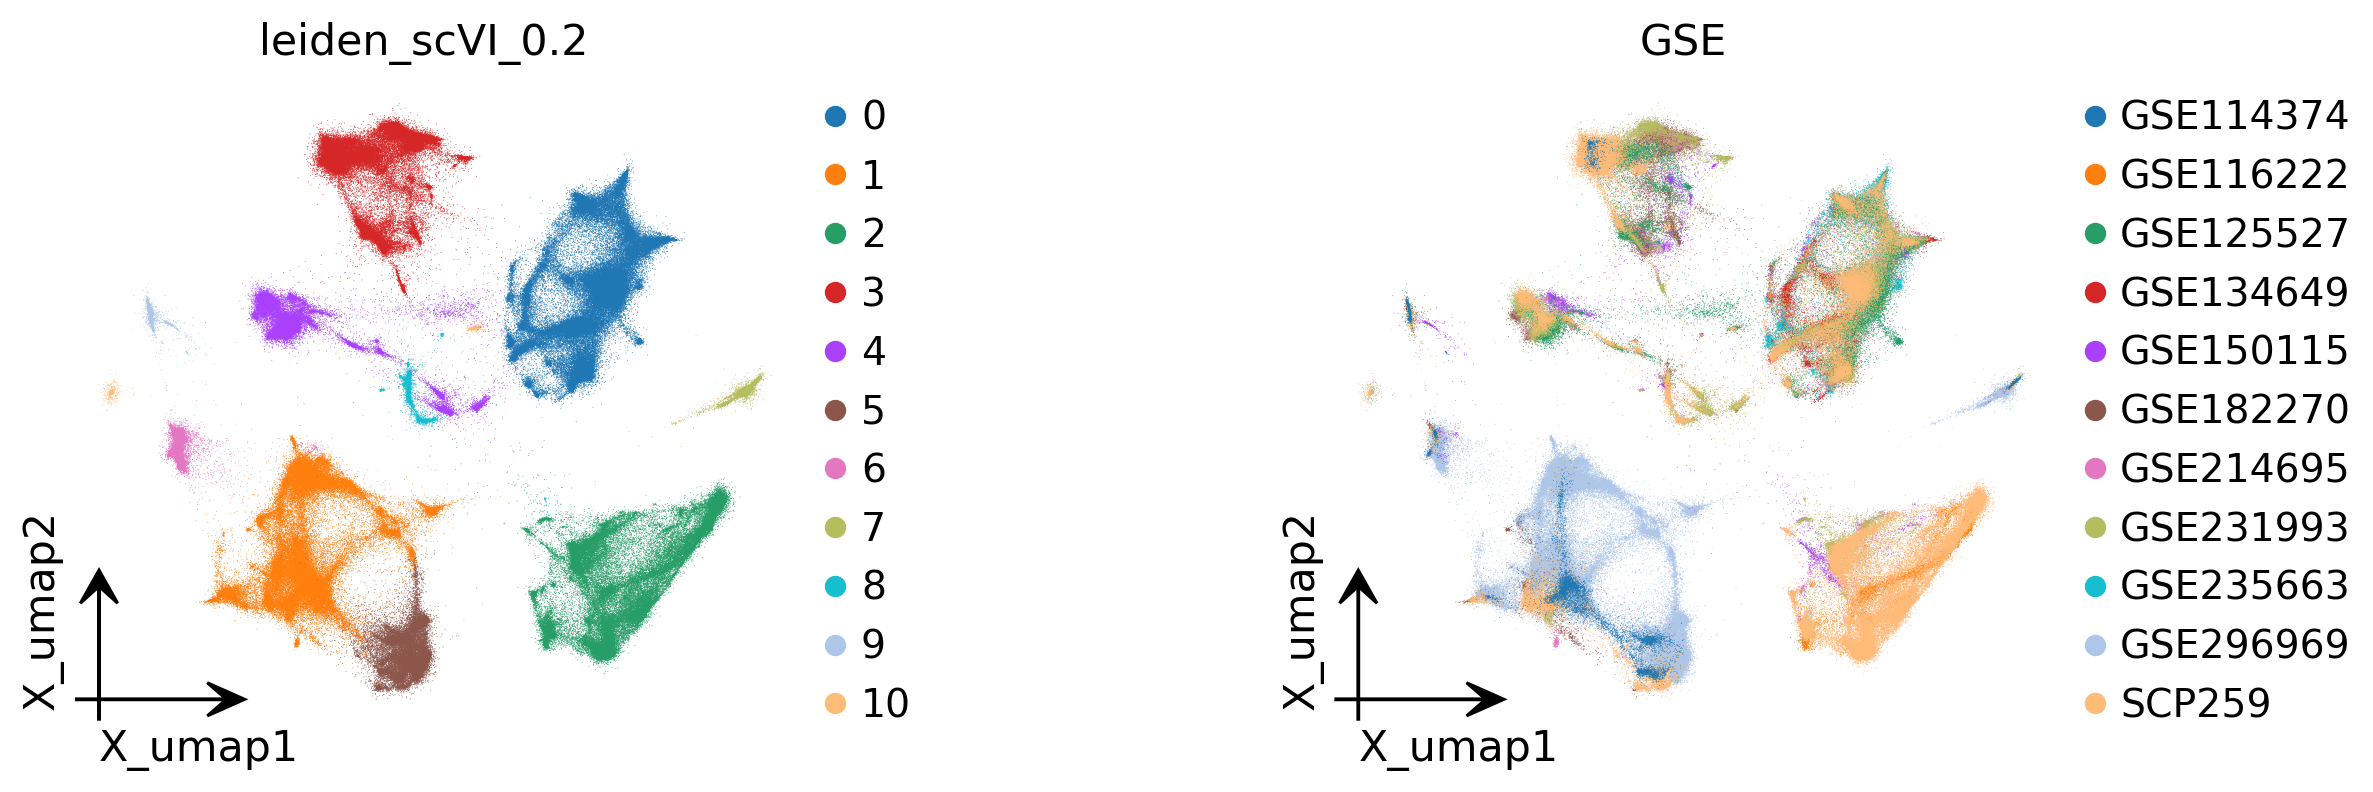

In [11]:
ov.pl.embedding(adata,
                basis='X_umap',
                color=['leiden_scVI_0.2', 'GSE'],
                frameon='small',
                wspace=0.5)   

## 5.保存

In [13]:
adata.write_h5ad(OUT_PATH, compression="gzip")
print(f"✅ 已保存：{OUT_PATH}")

✅ 已保存：/mnt/c/Users/Future/Nutstore/1/UC/scRNA-seq_data/05_scvi_integrated/tissue_dataset_scvi.h5ad


## GPT自动注释

In [14]:
# 获取每个细胞群的基因
all_markers = ov.single.get_celltype_marker(adata,
                                            clustertype='leiden_scVI_0.2',
                                            rank=True,
                                            key='rank_genes_groups',
                                            foldchange=1,
                                            topgenenumber=10)
all_markers

...get cell type marker
ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:01:03)


{'0': ['CD52',
  'CD3D',
  'SRGN',
  'IL32',
  'CD3E',
  'CD7',
  'PTPRC',
  'ARHGDIB',
  'CD2',
  'CORO1A'],
 '1': ['A2M',
  'DCN',
  'CFH',
  'C1R',
  'COL1A2',
  'COL3A1',
  'CFD',
  'COL1A1',
  'C1S',
  'FBLN1'],
 '10': ['VWA5A',
  'TYROBP',
  'ALOX5AP',
  'CAPG',
  'CD69',
  'SRGN',
  'NFKBIA',
  'SAMSN1',
  'ANXA1',
  'FCER1G'],
 '2': ['ELF3',
  'C15orf48',
  'KRT8',
  'CLDN7',
  'KRT19',
  'PHGR1',
  'LGALS4',
  'PIGR',
  'EPCAM',
  'KRT18'],
 '3': ['SEC11C',
  'FKBP11',
  'IGHA1',
  'DERL3',
  'IGKC',
  'MZB1',
  'XBP1',
  'HERPUD1',
  'SSR4',
  'IGHA2'],
 '4': ['CXCR4',
  'HLA-DRA',
  'CD74',
  'CD52',
  'CD37',
  'MS4A1',
  'LTB',
  'CD79A',
  'LAPTM5',
  'CD83'],
 '5': ['COL6A1',
  'LAMA4',
  'FRZB',
  'COL6A2',
  'COL1A2',
  'F3',
  'COL3A1',
  'COL1A1',
  'PLAT',
  'CALD1'],
 '6': ['RGS5',
  'COL4A1',
  'MYL9',
  'NOTCH3',
  'IGFBP7',
  'C11orf96',
  'MCAM',
  'NR2F2',
  'ADAMTS1',
  'CALD1'],
 '7': ['CRYAB',
  'CLU',
  'ALDH1A1',
  'SEMA3B',
  'PRNP',
  'SPARC',
  'MATN2'

In [15]:
import os
os.environ['AGI_API_KEY'] = 'sk-b54d8fd2ec144ce78b32602024fba248'
result = ov.single.gptcelltype(all_markers,
                               tissuename='colon tissue',
                               speciename='human',
                               model='qwen-plus',
                               provider='qwen',
                               topgenenumber=10)
result

Note: AGI API key found: returning the cell type annotations.
Note: It is always recommended to check the results returned by GPT-4 in case of AI hallucination, before going to downstream analysis.


{'0': 'T cell',
 '1': 'fibroblast',
 '10': 'myeloid cell',
 '2': 'epithelial cell',
 '3': 'plasma cell',
 '4': 'B cell',
 '5': 'fibroblast',
 '6': 'pericyte',
 '7': 'neuron-associated cell',
 '8': 'macrophage',
 '9': 'endothelial cell'}

In [16]:
# 添加识别结果到obs
adata.obs['gpt_celltype'] = adata.obs['leiden_scVI_0.2'].map(result).astype('category')

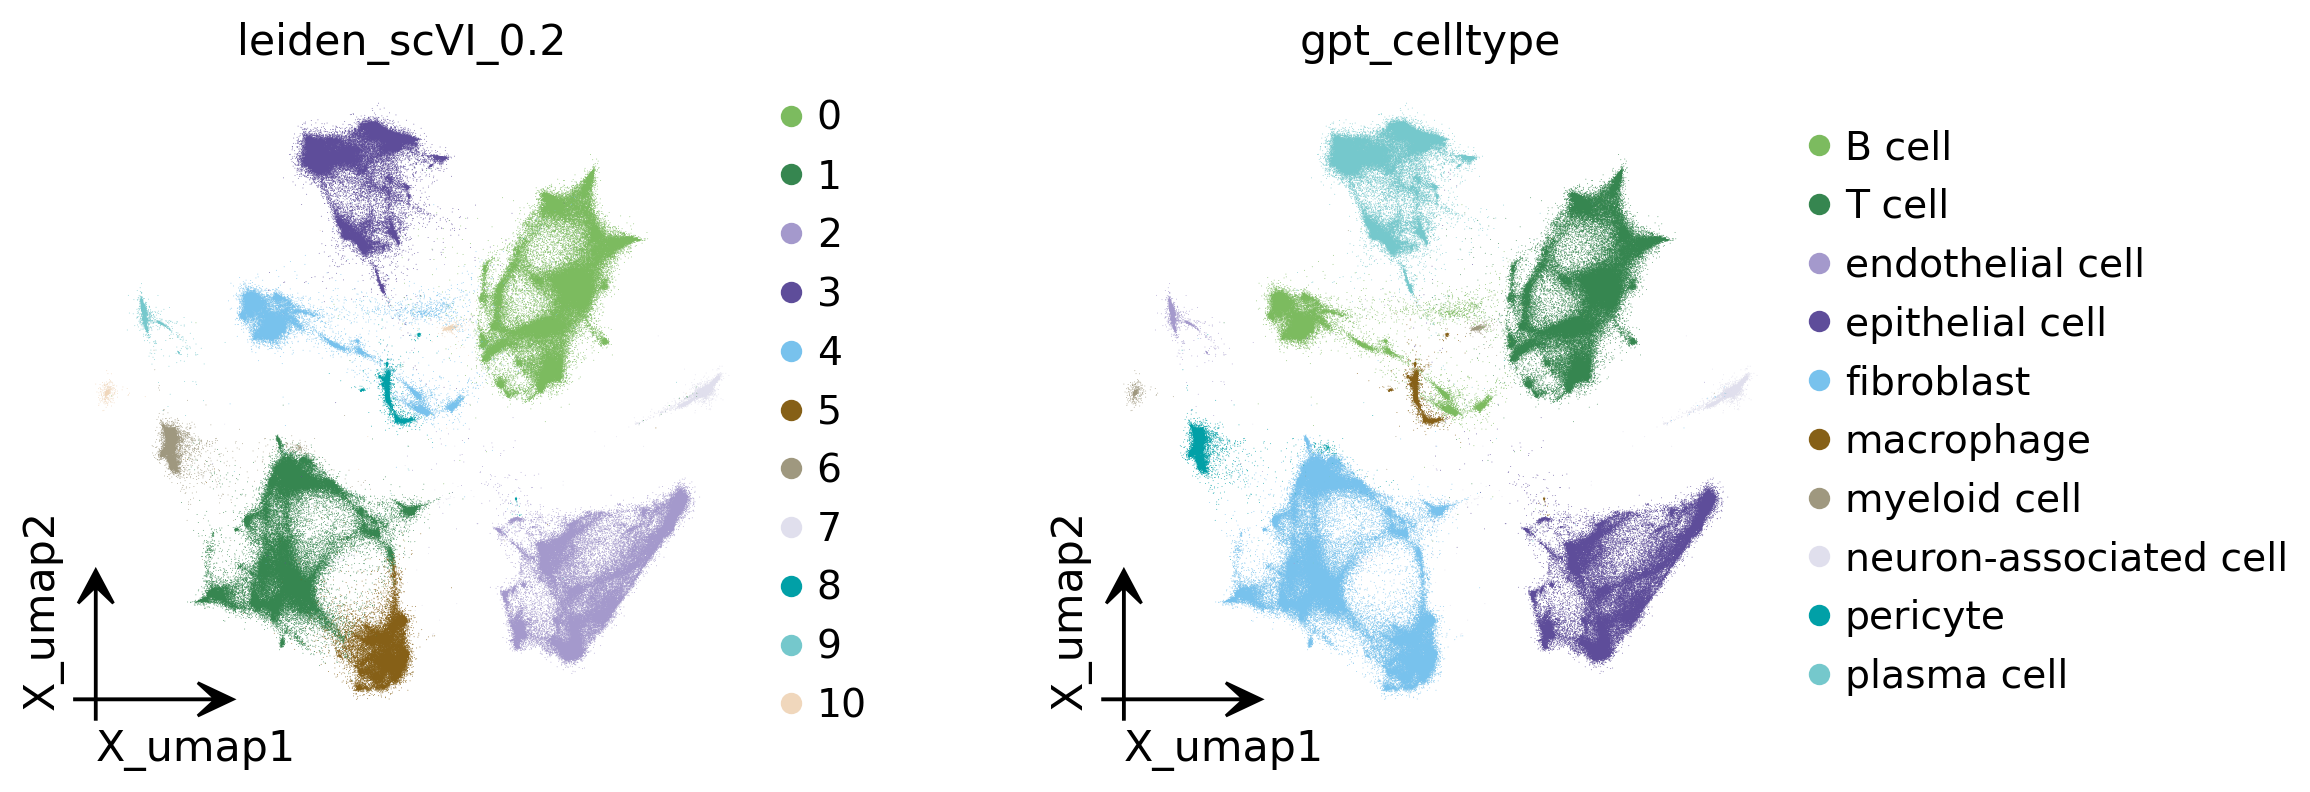

In [18]:
# 可视化查看结果
ov.pl.embedding(adata,
                basis='X_umap',
                color=['leiden_scVI_0.2', 'gpt_celltype'],
                # legend_loc='on data',
                frameon='small',
                legend_fontoutline=0.5,
                palette=ov.utils.palette()[10:],
                wspace=0.3)

In [19]:
# 统计每种细胞类型数量及占比
celltype_counts = adata.obs['gpt_celltype'].value_counts(normalize=True) * 100
print(celltype_counts)

gpt_celltype
fibroblast                26.557314
T cell                    23.454034
epithelial cell           17.317433
plasma cell               15.734819
B cell                     8.025751
pericyte                   2.706491
neuron-associated cell     2.051497
macrophage                 1.934009
endothelial cell           1.337492
myeloid cell               0.881158
Name: proportion, dtype: float64
